# 06 · Convergence and caching

Two questions every FDTD user hits: *how fine a mesh do I actually need?* and
*how do I avoid paying for the same run twice?* `gds_fdtd` answers both:

- **`convergence.sweep`** reruns one job while stepping a single
  `SimulationSpec` field (here `mesh`) and measures how much the S-matrix still
  moves — so you pick the coarsest grid that's already converged.
- **`run_cached`** hashes the geometry + technology + spec + engine version;
  a repeat job loads the stored S-matrix instead of recomputing it.

And a third, harder question (§4): *is my converged answer even correct?* —
where a beamz sweep is cross-checked against recorded tidy3d on a device that
breaks it. §1–3 run on free **beamz**; §4 adds recorded tidy3d, so the whole
notebook still reproduces without spending anything.

In [1]:
import json
import tempfile
import time
from pathlib import Path

import gdsfactory as gf
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.convergence import sweep
from gds_fdtd.layout.gdsfactory import from_gdsfactory
from gds_fdtd.lyprocessor import load_cell
from gds_fdtd.plotting import plot_component, plot_permittivity
from gds_fdtd.simprocessor import load_component_from_tech
from gds_fdtd.solvers import get_solver
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)

## 1 · A mesh convergence sweep

A short straight waveguide, run at three mesh densities. `sweep` returns a
`ConvergenceReport`; `max |ΔS|` is the worst-case change, between successive
meshes, of any S-parameter carrying real power. We set `floor_db=-10` so the
metric tracks the **transmission** and ignores the straight's deep reflection —
on a well-matched device that reflection is pure numerical noise and swings
tens of dB between meshes while being equally "zero" (see
`convergence.max_delta_db`). A `cache_dir` means the sweep only ever pays for
genuinely new points.

In [2]:
gf.gpdk.PDK.activate()
tech = Technology.from_yaml(_find("examples/tech.yaml"))
component = from_gdsfactory(gf.components.straight(length=1.5), tech)
spec = SimulationSpec(wavelength_start=1.5, wavelength_end=1.6, wavelength_points=3,
                      z_min=-0.6, z_max=0.8)

cache = Path(tempfile.mkdtemp(prefix="gdsfdtd_conv_"))
mesh_values = [4, 6, 8]
TOL_DB = 0.25  # engineering tolerance — convergence is always relative to it

t0 = time.perf_counter()
report = sweep(get_solver("beamz"), component, tech, spec,
               field="mesh", values=mesh_values, cache_dir=cache, floor_db=-10.0)
cold = time.perf_counter() - t0

for lo, hi, d in zip(mesh_values, mesh_values[1:], report.deltas_db):
    print(f"mesh {lo} → {hi}:  max |ΔS| = {d:.3f} dB")
print(f"\nsweep wall time (all new points): {cold:.1f} s")

● Done: Raster cache hit (3d): 25986b9b7a7be653deb9ea6a34dcab2289effc66e6128271da9aa4bbd05b653a.npz | load=0.00s


● Done: Raster cache hit (3d): cb29a8da54e62e698f0312c5fdb2a016ca08b9ee421449c81bde6484a49ab33c.npz | load=0.01s


● Done: Raster cache hit (3d): 11be3c871fecf7df3d7f924955359cae6c4fc2b1c32fbe830f439d2d0d4e50ed.npz | load=0.03s


mesh 4 → 6:  max |ΔS| = 1.099 dB
mesh 6 → 8:  max |ΔS| = 0.219 dB

sweep wall time (all new points): 128.5 s


The change shrinks as the mesh refines — the coarsest grid is off by ~1 dB,
then it settles. Plotted against the tolerance line:

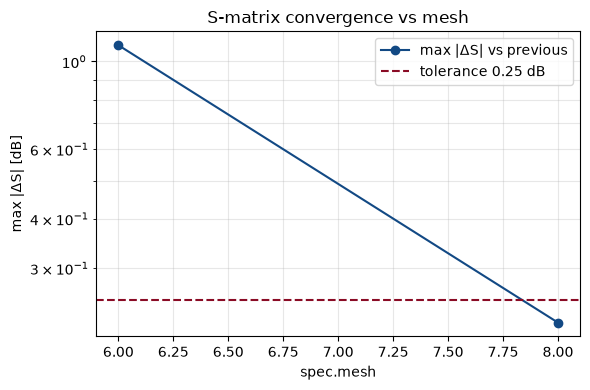

In [3]:
report.plot(tol_db=TOL_DB)
plt.show()

## 2 · The recommended mesh

`recommend` returns the coarsest mesh whose S-matrix had already stopped
moving (< `tol_db` from the previous step) — the one to use for production
runs. Finer than that just burns compute for no accuracy. The tolerance is
*your* engineering call: a foundry spec of ±0.25 dB converges here, while a
strict 0.05 dB would demand a finer sweep.

In [4]:
rec = report.recommend(tol_db=TOL_DB)
print(f"recommended mesh (tol {TOL_DB} dB): {rec}" if rec is not None
      else "not converged — extend the sweep to finer meshes")

recommended mesh (tol 0.25 dB): 8


## 3 · The cache makes repeats free

Every point above was stored under a content hash. Re-running the **identical
sweep** recomputes nothing — each job is a cache hit, so it returns almost
instantly. Change the geometry, technology, spec, or engine version and the
hash changes, so only the genuinely new work reruns.

In [5]:
t0 = time.perf_counter()
again = sweep(get_solver("beamz"), component, tech, spec,
              field="mesh", values=mesh_values, cache_dir=cache, floor_db=-10.0)
warm = time.perf_counter() - t0

print(f"cold sweep (new points): {cold:6.1f} s")
print(f"warm sweep (all cached): {warm:6.3f} s   →  {cold / max(warm, 1e-6):.0f}× faster")
print(f"identical result: {again.recommend(TOL_DB) == rec}")

cold sweep (new points):  128.5 s
warm sweep (all cached):  0.005 s   →  27776× faster
identical result: True


## 4 · When mesh isn't enough — cross-engine convergence on a hard device

A convergence sweep tells you when an engine has *stopped changing* — not
whether it stopped at the *right* answer. On a benign device (a straight) those
are the same thing. On a hard one they are not, and the only way to know is to
**cross-check a second engine**.

The device: **`sbend_dontfabme`** (from `examples/devices.gds`) — a
deliberately *sharp* S-bend that offsets the waveguide by 0.5 µm in just ~1 µm.
A bend this tight strongly **converts the fundamental mode into higher-order
modes and radiation**, so its true insertion loss is large. We run **beamz
live** and overlay **recorded tidy3d** results (in `recorded/`, so this
reproduces for free — no tidy3d key needed).

First, the geometry both engines rasterize from the same layout + technology:

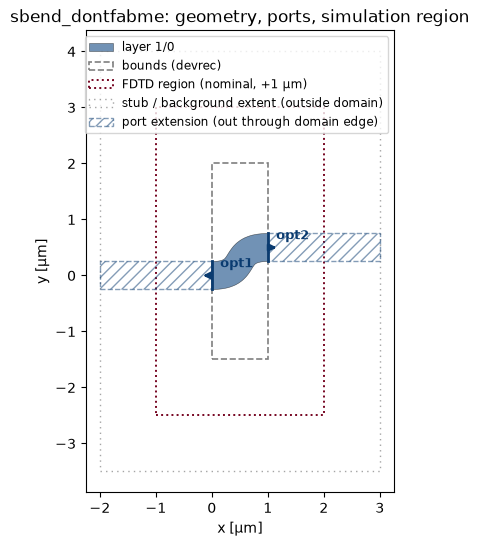

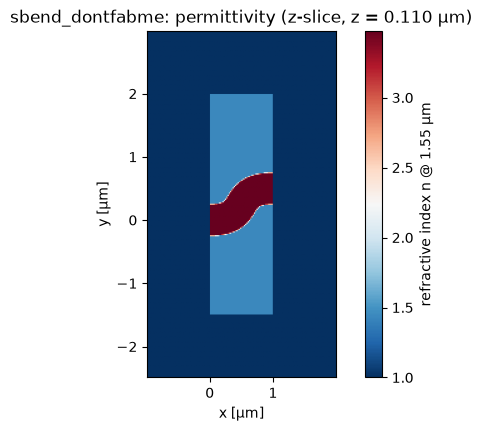

In [6]:
sbend_cell, _ = load_cell(str(_find("examples/devices.gds")), top_cell="sbend_dontfabme")
sbend = load_component_from_tech(cell=sbend_cell, tech=tech)
sbend.name = "sbend_dontfabme"
plot_component(sbend, spec=SimulationSpec())
plt.show()
plot_permittivity(sbend, axis="z", position=0.11, wavelength_um=1.55)  # top-down √ε at the Si core
plt.show()

Now the single-wavelength (1.55 µm) mesh sweep. beamz runs on the CPU here, so
we stop at mesh 10 — cost scales ~mesh³ and this device is already slow; the
recorded tidy3d curve carries the genuinely-high-mesh end (up to 25), which the
cloud reaches cheaply.

In [7]:
def _s_at_1550(sm, out, in_):
    i = int(np.argmin(np.abs(sm.wavelength_um - 1.55)))
    return float(sm.magnitude_db(out=out, in_=in_)[i])


beamz_sb = {}
field_solver = None
for m in [3, 4, 6, 8, 10]:
    spec_m = SimulationSpec(wavelength_start=1.5, wavelength_end=1.6, wavelength_points=3,
                            mesh=m, z_min=-1.0, z_max=1.11)
    solver = get_solver("beamz")(sbend, technology=tech, spec=spec_m)
    sm = solver.run()
    beamz_sb[m] = (_s_at_1550(sm, "opt2", "opt1"), _s_at_1550(sm, "opt1", "opt1"))
    if m == 10:
        field_solver = solver  # keep this one for its field profile below
    print(f"beamz mesh {m:>2}: S21={beamz_sb[m][0]:+.2f} dB  S11={beamz_sb[m][1]:+.2f} dB")

t3d_sb = json.loads(
    (_find("examples/06_convergence_and_caching/recorded/sbend_tidy3d_convergence.json")).read_text()
)["mesh"]

● Done: Raster cache hit (3d): 1a2bfa42a50202178b1be85463b8656cd77a2eb38b27960cf44597feb61fbfba.npz | load=0.00s


beamz mesh  3: S21=-4.63 dB  S11=-24.74 dB
● Info: Auto-selecting 3D meshing for 3D design
● Rasterizing 3D structures...


● Rasterizing 3D structures... done (2/2)
● Info: 3D raster timing: setup=0.00s, structures=1.96s, pml=0.00s, total=1.96s
● Info: 3D raster kernels: fast_enabled=False, fast_rect=0, fast_poly=0, fallback=1
● Done: Created 3D mesh: 62 × 62 × 46 cells
● Info: Raster cache saved: 51be56e948acffb65f1716f81645a399c0532aea4c0209e875ec1bd4ac74d232.npz | save=0.03s
● Info: Rasterize wall-time: 1.96s | total=1.99s


beamz mesh  4: S21=-4.39 dB  S11=-30.16 dB
● Info: Auto-selecting 3D meshing for 3D design
● Rasterizing 3D structures...


● Rasterizing 3D structures... done (2/2)
● Info: 3D raster timing: setup=0.00s, structures=5.27s, pml=0.00s, total=5.27s
● Info: 3D raster kernels: fast_enabled=False, fast_rect=0, fast_poly=0, fallback=1
● Done: Created 3D mesh: 94 × 94 × 70 cells
● Info: Raster cache saved: 8a4349ed918008e5ee7dfda76149d363115b52bcddc6d281766835674230be26.npz | save=0.11s
● Info: Rasterize wall-time: 5.27s | total=5.38s


beamz mesh  6: S21=-2.70 dB  S11=-37.32 dB
● Info: Auto-selecting 3D meshing for 3D design
● Rasterizing 3D structures...
● Rasterizing 3D structures... done (2/2)
● Info: 3D raster timing: setup=0.01s, structures=0.01s, pml=0.00s, total=0.02s
● Info: 3D raster kernels: fast_enabled=True, fast_rect=0, fast_poly=1, fallback=0
● Done: Created 3D mesh: 125 × 125 × 93 cells


● Info: Raster cache saved: 215a7bd89799b9c895f4dd6413fa89d244ba3d0dfd673f3c8e9227d1a1d821d8.npz | save=0.25s
● Info: Rasterize wall-time: 0.02s | total=0.28s


beamz mesh  8: S21=-4.68 dB  S11=-25.57 dB
● Info: Auto-selecting 3D meshing for 3D design
● Rasterizing 3D structures...
● Rasterizing 3D structures... done (2/2)
● Info: 3D raster timing: setup=0.01s, structures=0.01s, pml=0.00s, total=0.03s
● Info: 3D raster kernels: fast_enabled=True, fast_rect=0, fast_poly=1, fallback=0
● Done: Created 3D mesh: 156 × 156 × 117 cells


● Info: Raster cache saved: 5037b35efc8a3aad6d9e2bad66fa6a4b6f7da79bb315a7567301cc7314998be1.npz | save=0.50s
● Info: Rasterize wall-time: 0.03s | total=0.53s


beamz mesh 10: S21=-2.91 dB  S11=-23.58 dB


S21 on the left axis, S11 on the right. tidy3d converges **cleanly and
monotonically** to ≈ −5.6 dB; beamz **never settles** and plateaus ~3 dB
higher (≈ −2.8 dB). It isn't a mesh problem — beamz is stuck at the *wrong*
value, so more cells won't fix it.

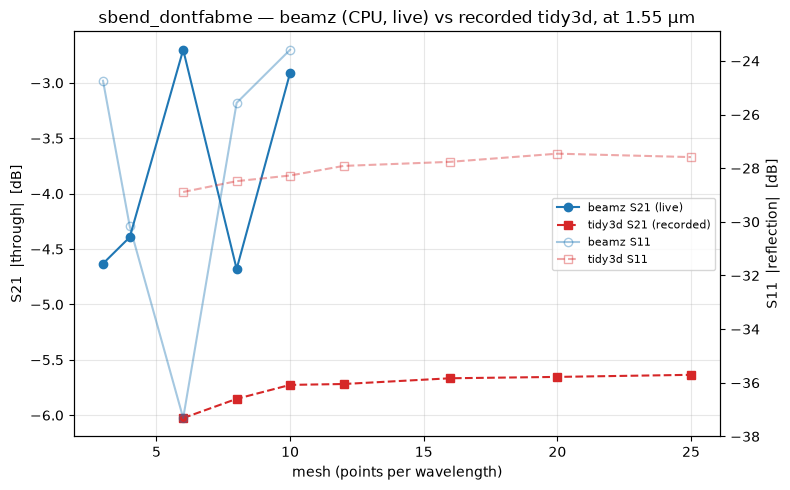

In [8]:
fig, axL = plt.subplots(figsize=(8, 5))
axR = axL.twinx()
bm = sorted(beamz_sb)
tm = sorted(int(m) for m in t3d_sb)
axL.plot(bm, [beamz_sb[m][0] for m in bm], "o-", color="tab:blue", label="beamz S21 (live)")
axL.plot(tm, [t3d_sb[str(m)]["s21_db"] for m in tm], "s--", color="tab:red", label="tidy3d S21 (recorded)")
axR.plot(bm, [beamz_sb[m][1] for m in bm], "o-", color="tab:blue", alpha=0.4,
         markerfacecolor="none", label="beamz S11")
axR.plot(tm, [t3d_sb[str(m)]["s11_db"] for m in tm], "s--", color="tab:red", alpha=0.4,
         markerfacecolor="none", label="tidy3d S11")
axL.set_xlabel("mesh (points per wavelength)")
axL.set_ylabel("S21  |through|  [dB]")
axR.set_ylabel("S11  |reflection|  [dB]")
axL.set_title("sbend_dontfabme — beamz (CPU, live) vs recorded tidy3d, at 1.55 µm")
axL.grid(True, alpha=0.3)
_lines = axL.get_lines() + axR.get_lines()
axL.legend(_lines, [ln.get_label() for ln in _lines], loc="center right", fontsize=8)
fig.tight_layout()
plt.show()

### Why they disagree — look at the field

Same setup, same mode injected at `opt1`; the difference is what happens at the
bend. Left: the **beamz** field (live). Right: the **recorded tidy3d** field.

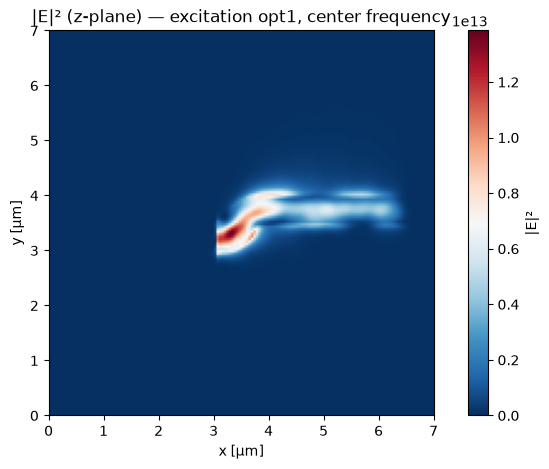

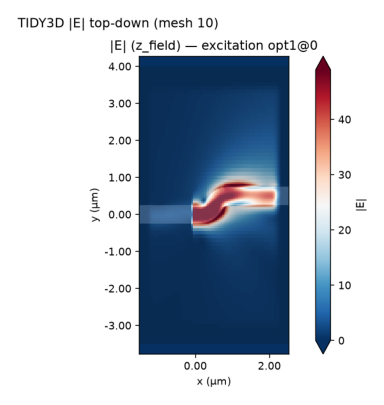

In [9]:
field_solver.plot_fields(axis="z")  # beamz |E|, live
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(mpimg.imread(str(_find("examples/06_convergence_and_caching/recorded/sbend_tidy3d_field.png"))))
ax.axis("off")
plt.show()

Turning the numbers into an energy budget at 1.55 µm: tidy3d
(S21 −5.6, S11 −27.6 dB) accounts for ~**72 %** of the input power radiated or
mode-converted away by the sharp bend; beamz (S21 ≈ −2.8 dB) sees only ~47 %.

The setup is correct on **both** — identical geometry, identical launched mode
(we verified the builds and fields). The gap is a **model** limitation: tidy3d
does a proper multi-mode modal decomposition at the ports, while beamz's v1
adapter uses single-mode, per-direction normalization, which under-counts the
mode conversion a tight bend produces. beamz is excellent for straights and
**adiabatic** transitions (it reproduced the `10_cookbook` Si→SiN escalator
within ~0.1 dB) — but a sharp, radiative bend like this one is outside its
comfort zone.

The lesson: **converged ≠ correct.** A convergence sweep is necessary but not
sufficient; for anything strongly multi-mode or radiative, cross-validate
against a second engine before you trust the number.

## Recap & next

`sweep` tells you the coarsest mesh that's *converged*; `run_cached` (and
`cache_dir=` on `sweep`) means you pay for each distinct job once; and — §4 —
convergence alone doesn't guarantee *correctness*, so cross-check a second
engine on hard (multi-mode / radiative) devices. Next:
**`07_choosing_an_engine`** — the same job on beamz, tidy3d, and Lumerical, and
how their results line up.